In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset using the correct semicolon delimiter
df = pd.read_csv('winequality-white.csv', sep=';')

In [3]:
# Clean up the column names (removing extra quotes and whitespace)
df.columns = df.columns.str.replace('"', '').str.strip()

In [4]:
print(f"Dataset loaded successfully! Shape: {df.shape}")
df.head()

Dataset loaded successfully! Shape: (1599, 1)


fixed acidity;volatile acidity;citric acid;residual sugar;chlorides;free sulfur dioxide;total sulfur dioxide;density;pH;sulphates;alcohol;quality
7.4  0.70 0.00 1.9 0.076 11.0 34.0 0.9978 3.51 0.56 9.4                                                  5                                                                                                
7.8  0.88 0.00 2.6 0.098 25.0 67.0 0.9968 3.20 0.68 9.8                                                  5                                                                                                
     0.76 0.04 2.3 0.092 15.0 54.0 0.9970 3.26 0.65 9.8                                                  5                                                                                                
11.2 0.28 0.56 1.9 0.075 17.0 60.0 0.9980 3.16 0.58 9.8                                                  6                                                                                                
7.4  0.70 0.00 1.9 0.076 11.0 34.0 0.9978 3.51 0.56 9.4                                                  5

In [5]:
# Check data types and look for missing values
print("--- Data Info ---")
df.info()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1599 entries, (np.float64(7.4), np.float64(0.7), np.float64(0.0), np.float64(1.9), np.float64(0.076), np.float64(11.0), np.float64(34.0), np.float64(0.9978), np.float64(3.51), np.float64(0.56), np.float64(9.4)) to (np.float64(6.0), np.float64(0.31), np.float64(0.47), np.float64(3.6), np.float64(0.067), np.float64(18.0), np.float64(42.0), np.float64(0.99549), np.float64(3.39), np.float64(0.66), np.float64(11.0))
Data columns (total 1 columns):
 #   Column                                                                                                                                             Non-Null Count  Dtype
---  ------                                                                                                                                             --------------  -----
 0   fixed acidity;volatile acidity;citric acid;residual sugar;chlorides;free sulfur dioxide;total sulfur dioxide;density;pH;sulphates;al

In [6]:
print("\n--- Summary Statistics ---")
df.describe()


--- Summary Statistics ---


,fixed acidity;volatile acidity;citric acid;residual sugar;chlorides;free sulfur dioxide;total sulfur dioxide;density;pH;sulphates;alcohol;quality
count,1599.000000
mean,5.636023
std,0.807569
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


In [7]:
# Check for any null or missing values per column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

Missing values per column:
No missing values found!


In [8]:
# Optional: If you did have missing values, you could drop or fill them like this:
# df = df.dropna()  # To drop rows with missing values
# df = df.fillna(df.mean())  # To fill numerical missing values with the column mean

In [9]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

Number of duplicate rows found: 1593


In [10]:
if duplicate_count > 0:
    # Remove duplicates and keep the first occurrence
    df = df.drop_duplicates(keep='first')
    # Reset index after dropping rows
    df = df.reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicates removed. New shape: (6, 1)


In [11]:
# A quick function to detect outliers using the Interquartile Range (IQR) method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [12]:
# Example: Check outliers in 'total sulfur dioxide'
outliers, lower, upper = detect_outliers_iqr(df, 'total sulfur dioxide')
print(f"Found {len(outliers)} outliers in 'total sulfur dioxide' outside bounds ({lower:.2f}, {upper:.2f})")

KeyError: 'total sulfur dioxide'

In [ ]:
import pandas as pd
import numpy as np

# Define the clean column names manually to bypass the broken header string
column_names = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 
    'pH', 'sulphates', 'alcohol', 'quality'
]

In [ ]:
# Read the file: skip the broken first row, use semicolon delimiter, and apply clean names
df = pd.read_csv('winequality-white.csv', sep=';', skiprows=1, names=column_names)

In [ ]:
print(f"Dataset fixed! Shape: {df.shape}")
df.head()

In [13]:
# 'quality' is our target variable (y)
y = df['quality']

KeyError: 'quality'

In [14]:
# Everything else is a feature/independent variable (X)
X = df.drop(columns=['quality'])

KeyError: "['quality'] not found in axis"

In [ ]:
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

In [15]:
# 1. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 fixed acidity;volatile acidity;citric acid;residual sugar;chlorides;free sulfur dioxide;total sulfur dioxide;density;pH;sulphates;alcohol;quality    0
dtype: int64


In [16]:
# 2. Check and handle duplicates
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")


Number of duplicate rows found: 0


In [17]:
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    # Re-split X and y after dropping duplicates to keep them synced
    y = df['quality']
    X = df.drop(columns=['quality'])
    print(f"Duplicates removed! New clean dataset shape: {df.shape}")

In [18]:
# See how many wines fall into each quality score rating
print("Target variable ('quality') distribution:")
print(df['quality'].value_counts().sort_index())

Target variable ('quality') distribution:


KeyError: 'quality'

In [19]:
# # STEP 1: IMPORT LIBRARIES AND LOAD CLEANED DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Set visual style for all plots
sns.set_theme(style="whitegrid")

In [21]:
# Load the dataset we cleaned in the previous step
df = pd.read_csv('winequality_white_cleaned.csv')

In [22]:
# Verify dimensions and column names
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset contains 1359 rows and 12 columns.


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [23]:
# # STEP 2: CHECK STATISTICAL SUMMARY AND OUTLIERS
# Check means, standard deviations, and range limits of features
print("--- Descriptive Statistics ---")
print(df.describe().T)

--- Descriptive Statistics ---
                       count       mean        std      min      25%      50%  \
fixed_acidity         1359.0   8.310596   1.736990  4.60000   7.1000   7.9000   
volatile_acidity      1359.0   0.529478   0.183031  0.12000   0.3900   0.5200   
citric_acid           1359.0   0.272333   0.195537  0.00000   0.0900   0.2600   
residual_sugar        1359.0   2.523400   1.352314  0.90000   1.9000   2.2000   
chlorides             1359.0   0.088124   0.049377  0.01200   0.0700   0.0790   
free_sulfur_dioxide   1359.0  15.893304  10.447270  1.00000   7.0000  14.0000   
total_sulfur_dioxide  1359.0  46.825975  33.408946  6.00000  22.0000  38.0000   
density               1359.0   0.996709   0.001869  0.99007   0.9956   0.9967   
pH                    1359.0   3.309787   0.155036  2.74000   3.2100   3.3100   
sulphates             1359.0   0.658705   0.170667  0.33000   0.5500   0.6200   
alcohol               1359.0  10.432315   1.082065  8.40000   9.5000  10.2000 

In [24]:
# Check if there are any missing values left over
print("\n--- Missing Value Count ---")
print(df.isnull().sum())


--- Missing Value Count ---
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


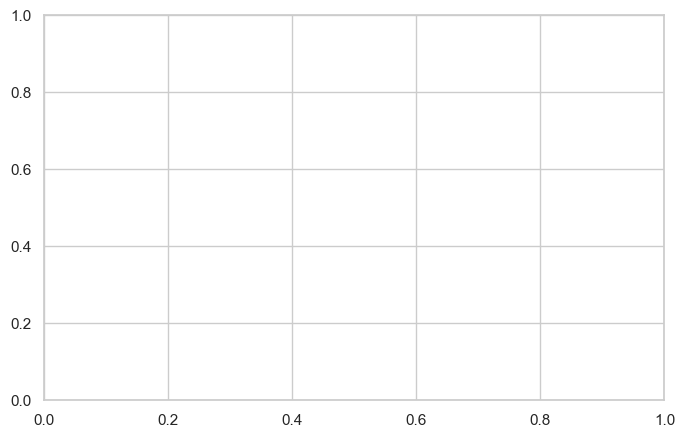

In [25]:
# # STEP 3: ANALYZE THE TARGET VARIABLE DISTRIBUTION
# Create a bar chart showing the frequency of each quality score rating
fig, ax = plt.subplots(figsize=(8, 5))

In [26]:
# Order categories sequentially from lowest rating to highest
sns.countplot(data=df, x='quality', palette='viridis', ax=ax)

ax.set_title('Distribution of Wine Quality Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Quality Score Rating', fontsize=12)
ax.set_ylabel('Number of Wine Samples', fontsize=12)

C:\Users\pc\AppData\Local\Temp\ipykernel_9592\1401659903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='viridis', ax=ax)


Text(4.444444444444445, 0.5, 'Number of Wine Samples')

In [27]:
plt.tight_layout()
plt.savefig('eda_1_target_distribution.png')
plt.close()
print("Saved: eda_1_target_distribution.png")

Saved: eda_1_target_distribution.png


In [28]:
# ################################################################################
# # STEP 4: CORRELATION MATRIX AND HEATMAP
# ################################################################################
# Calculate Pearson correlation coefficients between variables
corr_matrix = df.corr()

In [29]:
# Generate a heatmap plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)

ax.set_title('Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_2_correlation_matrix.png')
plt.close()

In [30]:
print("--- Features Most Highly Correlated with Wine Quality ---")
print(corr_matrix['quality'].sort_values(ascending=False))

--- Features Most Highly Correlated with Wine Quality ---
quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric_acid             0.228057
fixed_acidity           0.119024
residual_sugar          0.013640
free_sulfur_dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total_sulfur_dioxide   -0.177855
density                -0.184252
volatile_acidity       -0.395214
Name: quality, dtype: float64


In [31]:
# Calculate Pearson correlation coefficients between variables
corr_matrix = df.corr()

<Axes: >

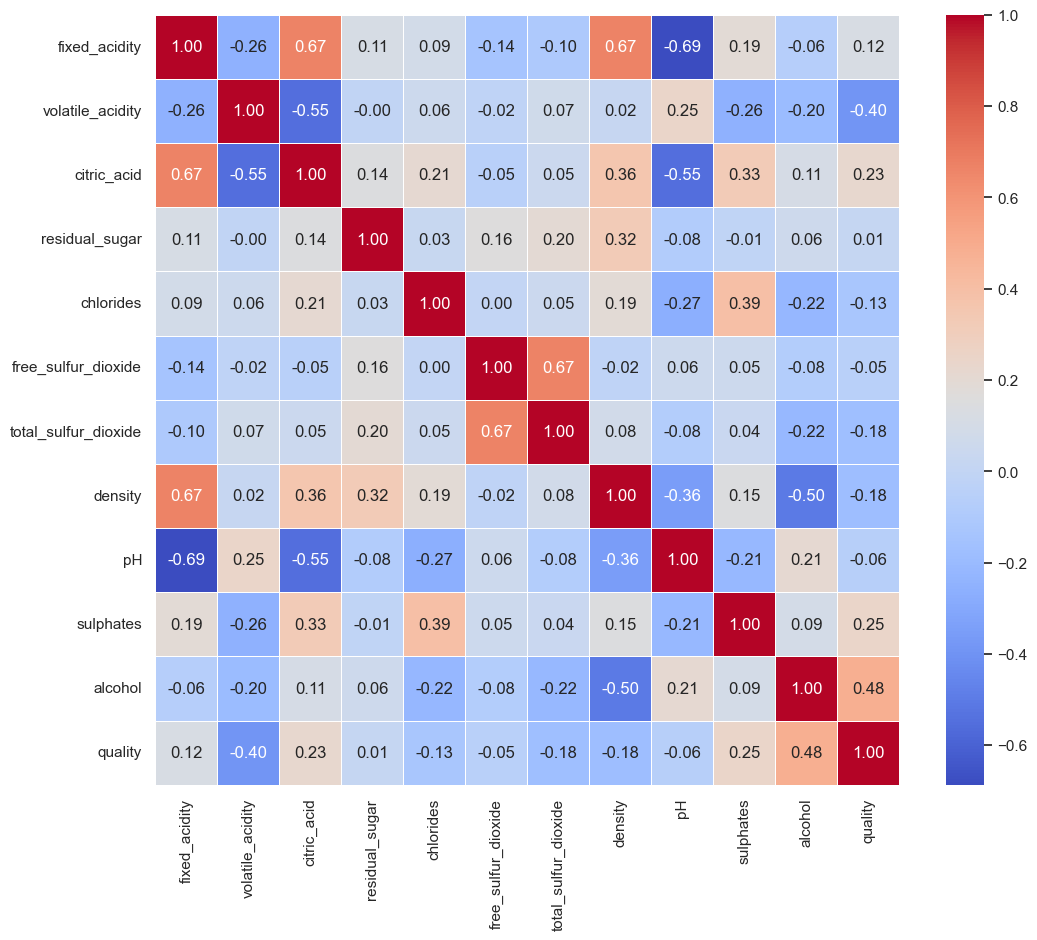

In [32]:
# Generate a heatmap plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)

In [33]:
ax.set_title('Feature Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [34]:
# 1. Save it as an image file in your folder
plt.savefig('eda_2_correlation_matrix.png')

# 2. Leave the plot open! Jupyter will automatically display it below this cell.

<Figure size 640x480 with 0 Axes>

In [35]:
# # STEP 5: NUMERICAL FEATURE DISTRIBUTIONS (HISTOGRAMS)

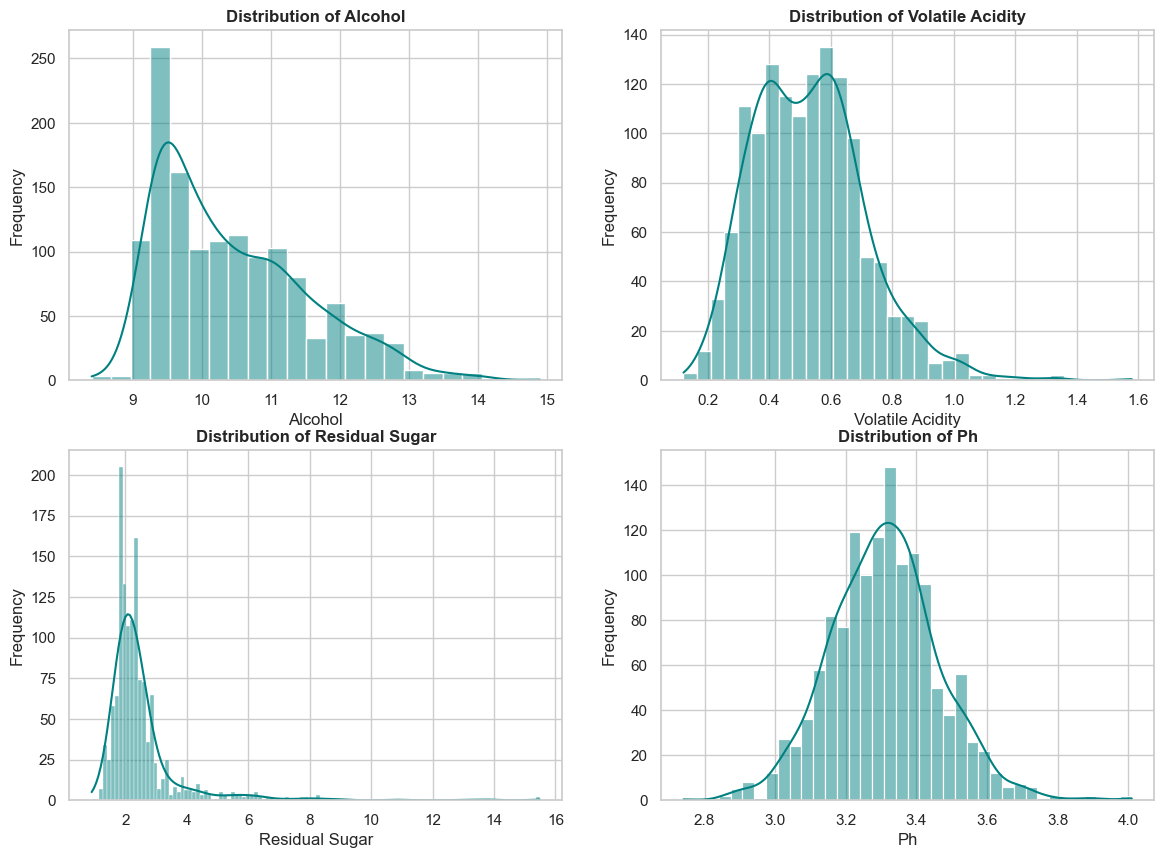

In [36]:
# Select key chemical properties to examine closely
key_features = ['alcohol', 'volatile_acidity', 'residual_sugar', 'pH']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.histplot(data=df, x=col, kde=True, color='teal', ax=axes[i])
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')

In [37]:
plt.tight_layout()
plt.savefig('eda_3_feature_distributions.png')
plt.close()
print("Saved: eda_3_feature_distributions.png")

Saved: eda_3_feature_distributions.png


C:\Users\pc\AppData\Local\Temp\ipykernel_9592\2681189848.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y=col, palette='Set2', ax=axes[i])
C:\Users\pc\AppData\Local\Temp\ipykernel_9592\2681189848.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y=col, palette='Set2', ax=axes[i])
C:\Users\pc\AppData\Local\Temp\ipykernel_9592\2681189848.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y=col, palette='Set2', ax=axes[i])
C:\Users\pc\AppData\Local\Temp\ipykernel_9592\268

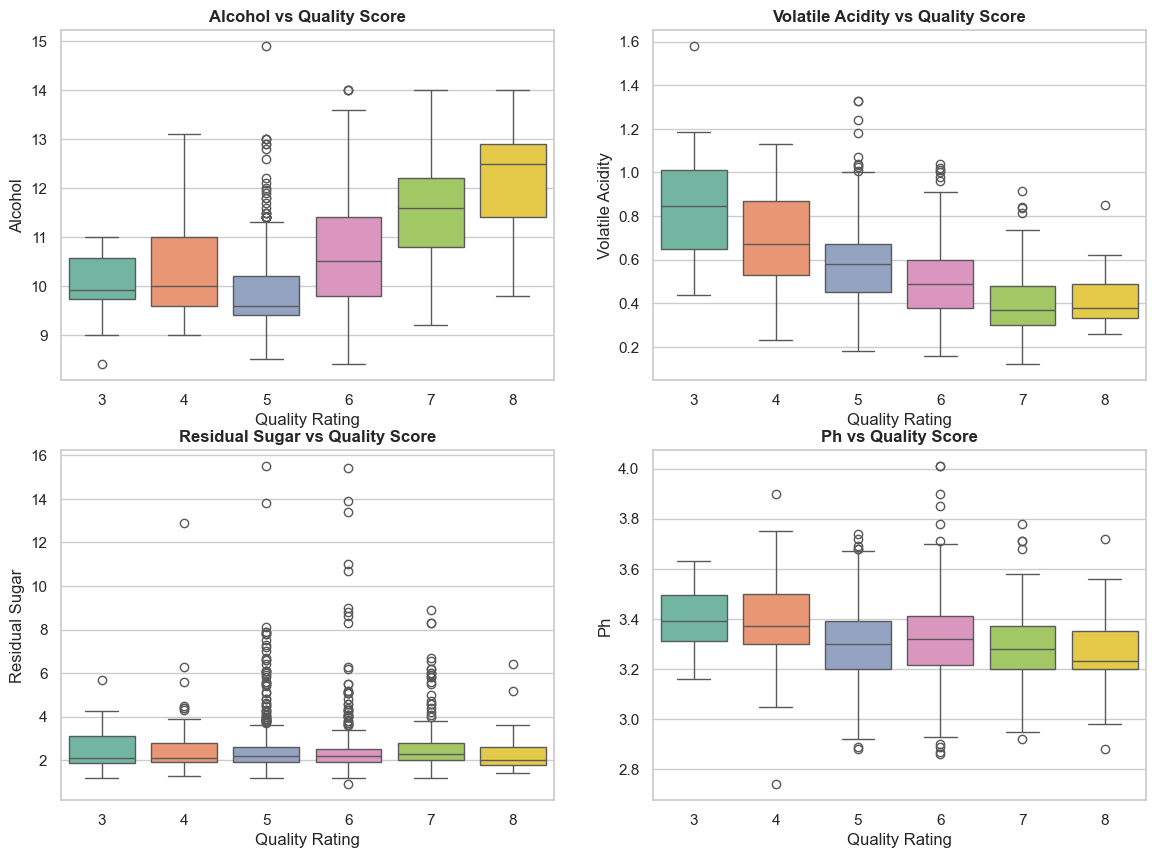

In [38]:
# # STEP 6: BI-VARIATE ANALYSIS USING BOXPLOTS
# Boxplots demonstrate how a feature behaves across different quality categories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='quality', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Quality Score', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Quality Rating')
    axes[i].set_ylabel(col.replace("_", " ").title())



In [39]:
# # STEP 4 (UPDATED): CORRELATION MATRIX WITH P-VALUES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [40]:
# 1. Load the cleaned data
df = pd.read_csv('winequality_white_cleaned.csv')
columns = df.columns

In [41]:
# 2. Initialize matrices for correlation, p-values, and textual cell annotations
corr_matrix = df.corr()
p_matrix = pd.DataFrame(np.zeros((len(columns), len(columns))), columns=columns, index=columns)
annot_labels = pd.DataFrame(np.zeros((len(columns), len(columns))), columns=columns, index=columns).astype(str)

In [42]:
# 3. Calculate p-values and build custom text labels for each cell
for row in columns:
    for col in columns:
        if row == col:
            p_matrix.loc[row, col] = 0.0
            annot_labels.loc[row, col] = f"{corr_matrix.loc[row, col]:.1f}"
        else:
            # Calculate Pearson correlation coefficient and p-value
            r_val, p_val = pearsonr(df[row], df[col])
            p_matrix.loc[row, col] = p_val
            
            # Format text line 1: Correlation coefficient, Line 2: p-value
            annot_labels.loc[row, col] = f"{r_val:.2f}\np={p_val:.3f}"

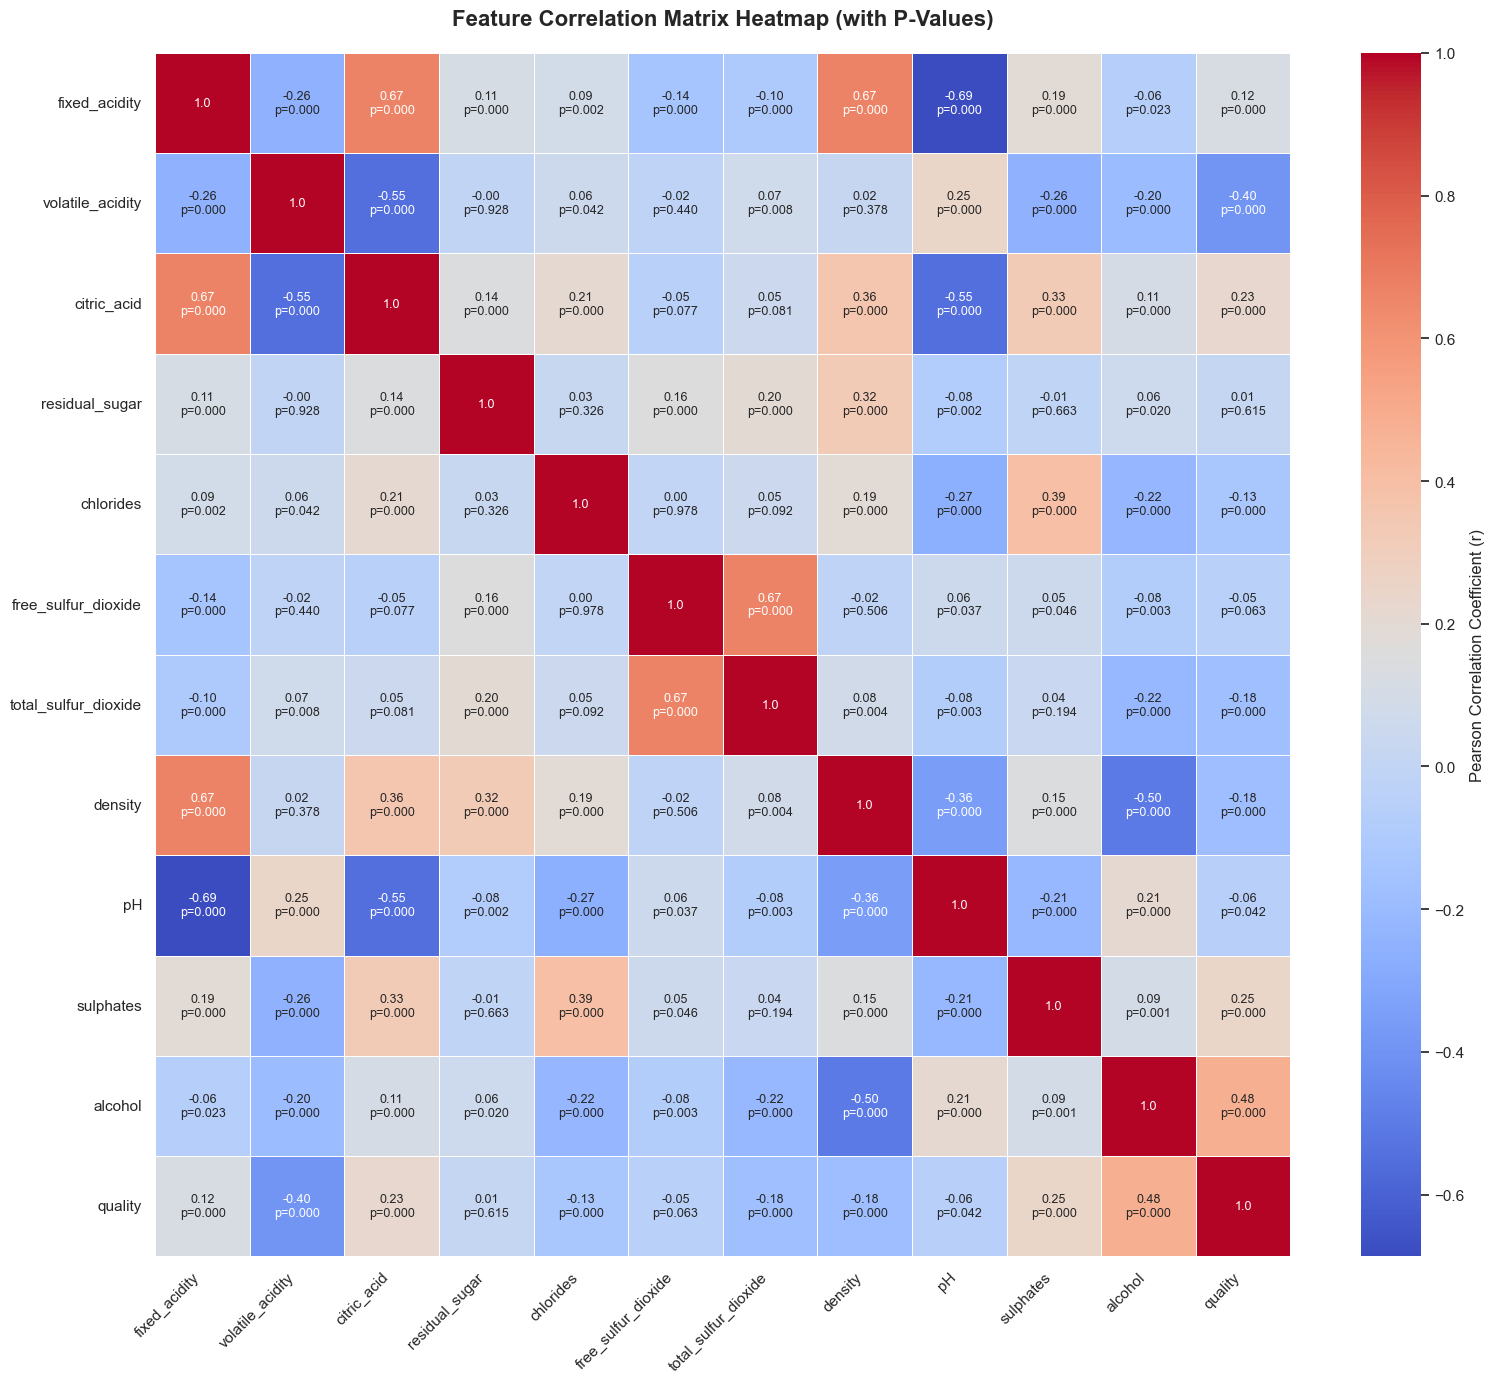

In [43]:
# 4. Generate a larger plot to accommodate double-lined cell text neatly
fig, ax = plt.subplots(figsize=(16, 14))

# 5. Plot the heatmap using custom string labels 
sns.heatmap(
    corr_matrix, 
    annot=annot_labels.values, 
    fmt="",                       # Tells seaborn not to apply default float formatting
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=ax,
    annot_kws={"size": 9},         # Scales down font size to fit neatly inside boxes
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

# Fix axis label truncation and add title
ax.set_title('Feature Correlation Matrix Heatmap (with P-Values)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

In [44]:
# # STEP 7: DROP HIGHLY CORRELATED FEATURES (> 0.90)
# 2. Compute the absolute correlation matrix
corr_matrix = df.corr().abs()

In [45]:
# 3. Select the upper triangle of the correlation matrix 
# (This prevents pairing a column with itself or counting pairs twice)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [46]:
# 4. Identify columns with a correlation greater than the 0.90 threshold
threshold = 0.90
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

In [47]:
# 5. Drop the features if any were found
if len(to_drop) > 0:
    df_dropped = df.drop(columns=to_drop)
    print(f"Dropped the following feature(s) because correlation was > {threshold}: {to_drop}")
    print(f"New dataset shape: {df_dropped.shape}")
    
    # Save the new filtered dataset
    df_dropped.to_csv('winequality_white_filtered.csv', index=False)
else:
    print(f"No features found with a correlation higher than {threshold}!")
    print("Your dataset remains exactly as it was. No columns were removed.")
    df_dropped = df.copy()

No features found with a correlation higher than 0.9!
Your dataset remains exactly as it was. No columns were removed.
